<a href="https://colab.research.google.com/github/dachshoon/Deeplearning_project1/blob/main/HW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 2 on Logistic Regression

This implementation of the logistic regression is the same as what you have leraned in the class. Therefore, it is important that you become familiar with every single line of the codes and know its meaning.

However, this code does not use any basis function and does not use the Hessian matrix but a fixed learning ratio in the gradient descent method to train.

Task 1. Know the meaning of this implementation in the line-by-line manner.

Task 2. Enhance its accuracy in a whatever way you want, e.g., implementing a basis function, implementing another optimizer instead of the gradient descent.

Submit a report for Task 2. Describe how you updated the codes and its decision boundary visualization (see the Plotting the decision boundary section). If you applied a basis function, redraw the updated decision boundary. For this visualization, you can refer to Scikit-Learn.

### Load the Data and Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
plt.style.use("ggplot")
%matplotlib inline

In [ ]:
from pylab import rcParams
rcParams['figure.figsize'] = 12, 8

In [ ]:
import pandas as pd
import io
from google.colab import files

uploaded = files.upload()
data=pd.read_csv("data.csv",index_col="t")
data.head()

Saving data.csv to data (2).csv


,x1,x2
t,,
0,34.623660,78.024693
0,30.286711,43.894998
0,35.847409,72.902198
1,60.182599,86.308552
1,79.032736,75.344376


In [ ]:
feature = data[["x1", "x2"]].values
class_label = data.index.values

### Visualize the Data

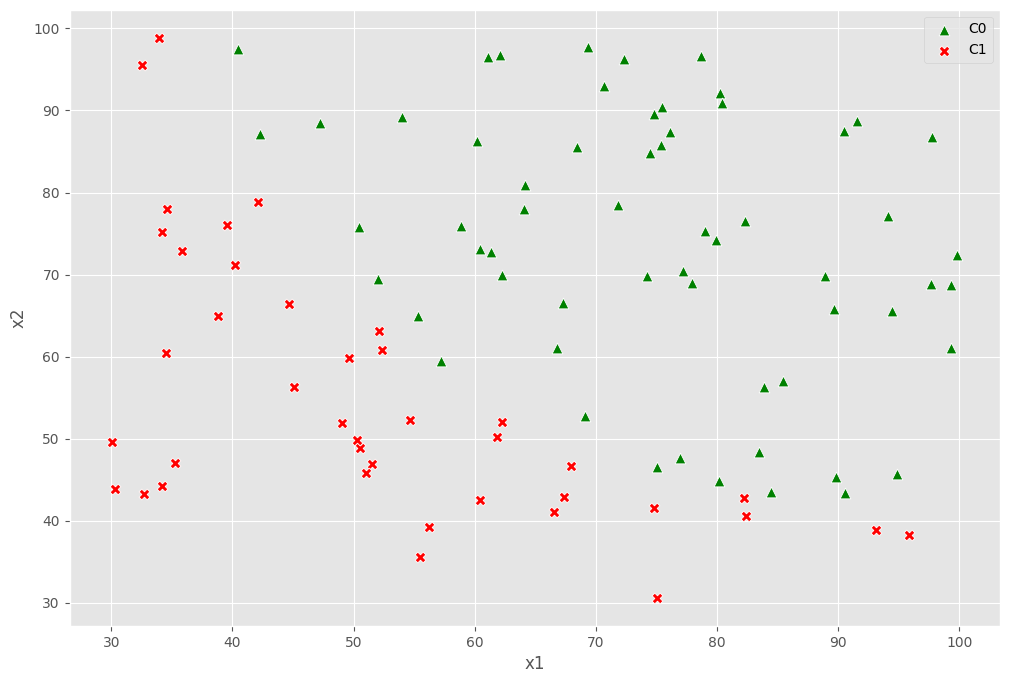

In [ ]:
class_c0 = (class_label == 1).reshape(100, 1)
class_c1 = (class_label == 0).reshape(100, 1)

ax = sns.scatterplot(x = feature[class_c0[:, 0], 0],
                     y = feature[class_c0[:, 0], 1],
                     marker = "^",
                     color = "green",
                     s = 60)
sns.scatterplot(x = feature[class_c1[:, 0], 0],
                y = feature[class_c1[:, 0], 1],
                marker = "X",
                color = "red",
                s = 60)

ax.set(xlabel="x1", ylabel="x2")
ax.legend(["C0", "C1"])
plt.show();

### Define the Logistic Sigmoid Function $\sigma(z)$

$$ \sigma(z) = \frac{1}{1+e^{-z}}$$

In [ ]:
def logistic_function(x):
    return 1/ (1 + np.exp(-x))

### Compute the Cost Function $J(\theta)$ and Gradient

$h_{\boldsymbol \theta}(\boldsymbol x) = \sigma(z)$, where $\sigma$ is the logistic sigmoid function and $z = \boldsymbol \theta^T \boldsymbol x$.

The objective of logistic regression is to minimize the cost function

$$J(\boldsymbol \theta) = -\frac{1}{m} \sum_{i=1}^{m} [ y^{(i)}log(h_{\boldsymbol \theta}(\boldsymbol x^{(i)})) + (1 - y^{(i)})log(1 - (h_{\boldsymbol \theta}(\boldsymbol x^{(i)}))]$$

where the gradient of the cost function is given by

$$ \frac{\partial J(\boldsymbol \theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^{m} (h_{\boldsymbol \theta}(\boldsymbol x^{(i)}) - y^{(i)})\boldsymbol x_j^{(i)}.$$

In [ ]:
def compute_cost(theta, x, y):
    m = len(y)
    y_pred = logistic_function(np.dot(x , theta))
    error = (y * np.log(y_pred)) + ((1 - y) * np.log(1 - y_pred))
    cost = -1 / m * sum(error)
    gradient = 1 / m * np.dot(x.transpose(), (y_pred - y))
    return cost[0] , gradient

### polynomial basis function

In [ ]:
def map_feature(x1, x2, degree):
    x1 = np.atleast_1d(x1)
    x2 = np.atleast_1d(x2)

    out = [np.ones(x1.shape[0])]
    for i in range(1, degree + 1):
        for j in range(i + 1):
            out.append((x1 ** (i - j)) * (x2 ** j))

    return np.column_stack(out)

### separate validation

In [ ]:
from sklearn.model_selection import train_test_split

mean_scores = np.mean(feature, axis=0)
std_scores = np.std(feature, axis=0)
scores = (feature - mean_scores) / std_scores

y = class_label.reshape(feature.shape[0], 1)

X_train, X_temp, y_train, y_temp = train_test_split(
    scores, y, test_size=0.4, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)


### Gradient Descent

Minimize the cost function $J(\boldsymbol \theta)$ by updating the below equation and repeat until convergence:
$\boldsymbol \theta_{j+1} := \boldsymbol \theta_j - \alpha \frac{\partial J(\boldsymbol \theta)}{\partial \boldsymbol \theta_j}$.

See https://en.wikipedia.org/wiki/Gradient_descent.

In [ ]:
def gradient_descent(x, y, theta, alpha, iterations):
    costs = []
    for i in range(iterations):
        cost, gradient = compute_cost(theta, x, y)
        theta -= (alpha * gradient)
        costs.append(cost)
    return theta, costs

### Newton Method

In [ ]:
def newton_method_reg(X, y, theta, iterations, lambda_reg=0.1):
    m = len(y)
    costs = []
    n = X.shape[1]

    for i in range(iterations):
        y_pred = logistic_function(np.dot(X, theta))

        reg_term = (lambda_reg / (2 * m)) * np.sum(np.square(theta[1:]))
        error = (y * np.log(y_pred + 1e-15)) + ((1 - y) * np.log(1 - y_pred + 1e-15))
        cost = -1 / m * np.sum(error) + reg_term
        costs.append(cost)

        gradient = 1 / m * np.dot(X.transpose(), (y_pred - y))
        gradient[1:] += (lambda_reg / m) * theta[1:]

        S = np.diag((y_pred * (1 - y_pred)).flatten())
        Hessian = 1 / m * np.dot(X.transpose(), np.dot(S, X))

        reg_matrix = np.eye(n)
        reg_matrix[0, 0] = 0
        Hessian += (lambda_reg / m) * reg_matrix

        Hessian += 1e-5 * np.eye(n)

        theta = theta - np.dot(np.linalg.pinv(Hessian), gradient)

    return theta, costs

### check the best degree

In [ ]:
def predict(theta, x):
    results = x.dot(theta)
    return results > 0


In [ ]:
degrees = [1, 2, 3, 4]
lambdas = [0, 0.01, 0.1, 1]
best_degree = 1
best_lambda = 0
best_val_acc = 0
best_theta = None
best_costs = None

for d in degrees:
    for l in lambdas:
        X_poly_train = map_feature(X_train[:, 0], X_train[:, 1], degree=d)
        X_poly_val = map_feature(X_val[:, 0], X_val[:, 1], degree=d)
        theta_init = np.zeros((X_poly_train.shape[1], 1))
        theta_opt, costs_opt = newton_method_reg(X_poly_train, y_train, theta_init, iterations=10, lambda_reg=l)
        p_val = predict(theta_opt, X_poly_val)
        val_acc = np.mean(p_val == y_val) * 100
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_degree = d
            best_lambda = l
            best_theta = theta_opt
            best_costs = costs_opt

print(f"- 최적 조합: Degree {best_degree}, Lambda {best_lambda}")
print(f"- 최적 Validation 정확도: {best_val_acc:.2f}%")

X_poly_test = map_feature(X_test[:, 0], X_test[:, 1], degree=best_degree)
p_test = predict(best_theta, X_poly_test)
test_acc = sum(p_test == y_test)[0] / len(y_test) * 100

print(f"- 최종 Test Accuracy: {test_acc:.2f}% ")

- 최적 조합: Degree 2, Lambda 0
- 최적 Validation 정확도: 100.00%
- 최종 Test Accuracy: 95.00% 


### Plotting the Convergence of $J(\boldsymbol \theta)$

Plot $J(\boldsymbol \theta)$ against the number of iterations of gradient descent:

<>:3: SyntaxWarning: invalid escape sequence '\T'
<>:3: SyntaxWarning: invalid escape sequence '\T'
/tmp/ipykernel_2635/2866976047.py:3: SyntaxWarning: invalid escape sequence '\T'
  plt.ylabel("$J(\Theta)$")


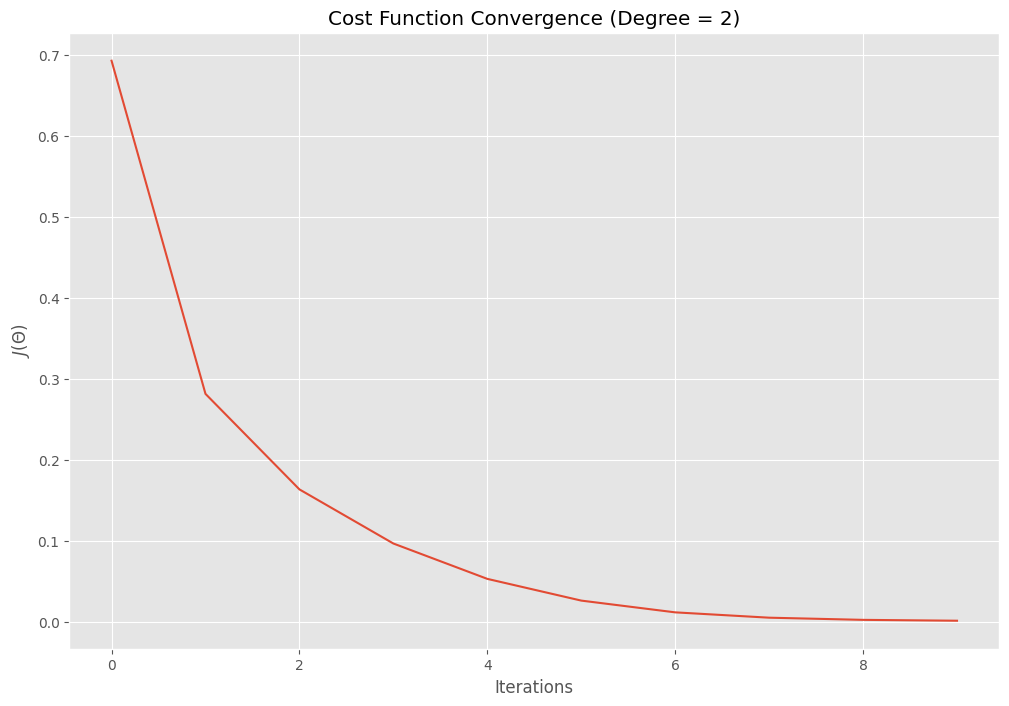

In [ ]:
plt.plot(best_costs)
plt.xlabel("Iterations")
plt.ylabel("$J(\Theta)$")
plt.title(f"Cost Function Convergence (Degree = {best_degree})")
plt.show()



```
# 코드로 형식 지정됨
```

### Plotting the decision boundary

$h_{\boldsymbol \theta}(\boldsymbol x) = \sigma(z)$, where $\sigma$ is the logistic sigmoid function and $z = \boldsymbol \theta^T \boldsymbol x$

When $h_{\boldsymbol \theta}(\boldsymbol x) \geq 0.5$ the model predicts class "1":

$\implies \sigma(\boldsymbol \theta^T \boldsymbol x) \geq 0.5$

$\implies \boldsymbol \theta^T \boldsymbol x \geq 0$ predict class "1"

Hence, $\theta_0 + \theta_1x_1 + \theta_2x_2 = 0$ is the equation for the decision boundary, giving us

$ x_2 = \frac{-(\theta_0+\theta_1x_1)}{\theta_2}$

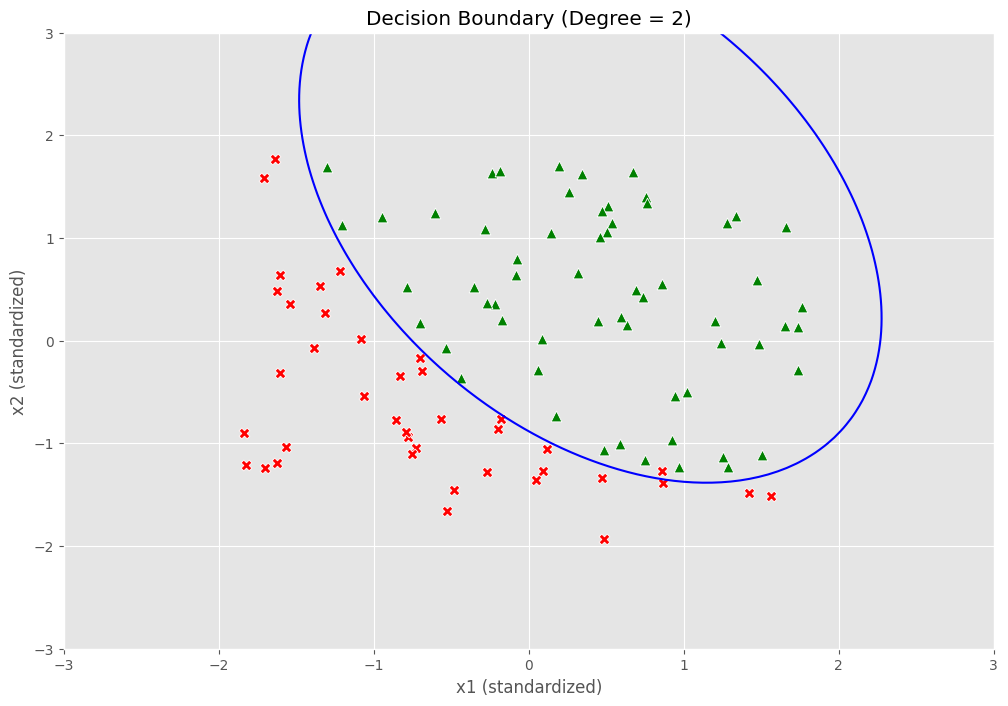

In [ ]:
# 표준화된 전체 데이터 산점도
ax = sns.scatterplot(x=scores[class_c0[:, 0], 0], y=scores[class_c0[:, 0], 1], marker="^", color="green", s=60)
sns.scatterplot(x=scores[class_c1[:, 0], 0], y=scores[class_c1[:, 0], 1], marker="X", color="red", s=60)
ax.set(xlabel="x1 (standardized)", ylabel="x2 (standardized)")

# 격자 생성
u = np.linspace(-3, 3, 100)
v = np.linspace(-3, 3, 100)
U, V = np.meshgrid(u, v)

# 격자를 최적의 다항식으로 변환하고 예측
grid_features = map_feature(U.ravel(), V.ravel(), degree=best_degree)
Z = grid_features.dot(best_theta)
Z = Z.reshape(U.shape)

# 결정 경계선 그리기 (Z=0인 지점)
plt.contour(U, V, Z, levels=[0], colors='blue')
plt.title(f"Decision Boundary (Degree = {best_degree})")
plt.show()

### Predictions using the optimized $\theta$ values

In [ ]:
X_poly_test = map_feature(X_test[:, 0], X_test[:, 1], degree=best_degree)

p_test = predict(best_theta, X_poly_test)

test_acc = sum(p_test == y_test)[0] / len(y_test) * 100
print(f"최종 실전 Test Accuracy: {test_acc:.2f} %")

최종 실전 Test Accuracy: 95.00 %


In [ ]:
test = np.array([50, 79])
test_std = (test - mean_scores) / std_scores

test_poly = map_feature(test_std[0], test_std[1], degree=best_degree)

probability = logistic_function(test_poly.dot(best_theta))

print("A test sample who x1 = 50 and x2 = 79 will be in the class of C1 in the probability of ",
      np.round(probability.flatten()[0], 2))

A test sample who x1 = 50 and x2 = 79 will be in the class of C1 in the probability of  1.0


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

svm_model.fit(X_train, y_train.flatten())

svm_predictions = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test.flatten(), svm_predictions) * 100

print(f"- Custom Logistic Regression (Degree={best_degree}): {test_acc:.2f}%")
print(f"- Scikit-Learn SVM (RBF Kernel): {svm_accuracy:.2f}%")

- Custom Logistic Regression (Degree=2): 95.00%
- Scikit-Learn SVM (RBF Kernel): 90.00%
